In [17]:
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from heisenberg_hamiltonians import HeisenbergJ1J2
from mvmc_configs import MVMCConfig
from spin_lattices import KagomeLattice, SquareLattice
from mvmc_kagome_2023_03_29 import system, experiment_dir

import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
%matplotlib inline

In [24]:
outfiles = pd.concat(
    [
        pd.read_csv(out_file, index_col=0)
        .reset_index()
        .assign(trial=out_file.stem.removeprefix("out_"))
        for out_file in ((experiment_dir / "out").glob("*.csv"))
    ],
    ignore_index=True,
)
outfiles = (
    outfiles.merge(
        (outfiles.groupby("trial").size() == 500).rename("good"), left_on="trial", right_index=True
    )
    .query("good")
    .drop("good", axis=1)
)


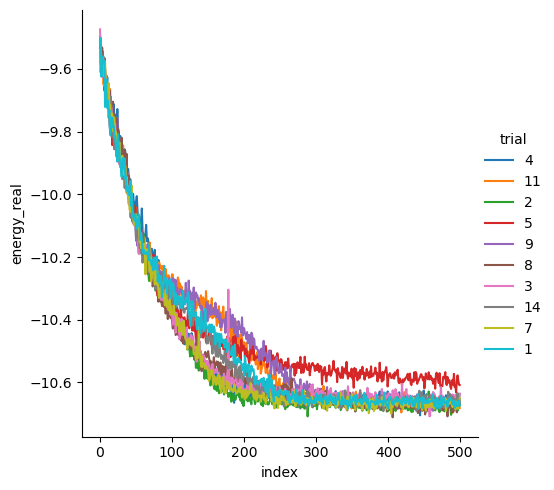

In [26]:
sns.relplot(outfiles, x='index', y='energy_real', hue='trial', kind='line')

In [28]:
wavefunctions = {trial: pd.read_csv(experiment_dir / "wavefunctions" / f"wavefunction_{trial}.csv")["eigenstate_coeff"] for trial in outfiles['trial'].unique()}
    

In [30]:
system.get_eigenstates(1)

2023-03-30 13:53:59.693 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:60 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-1-1.pickle
2023-03-30 13:53:59.761 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energy is -42.8245991763


(array([-42.82459918]),
 array([[ 3.68841196e-07],
        [ 1.08484503e-07],
        [-6.80321312e-19],
        ...,
        [-1.41331442e-05],
        [-1.67384289e-02],
        [ 3.56623895e-02]]))

In [32]:
ed_ground_state = system.get_df_eigenstate(canonical_basis=True, k=0)['eigenstate_coeff']

In [29]:
wavefunctions

{'4': 0          2.475353e-09
 1         -1.945902e-08
 2          1.249136e-08
 3         -6.446231e-08
 4         -1.694356e-07
                ...     
 2704151   -3.411517e-07
 2704152   -1.541136e-07
 2704153    2.730910e-08
 2704154   -7.426058e-09
 2704155    8.480375e-10
 Name: eigenstate_coeff, Length: 2704156, dtype: float64,
 '11': 0          6.365120e-08
 1         -9.309702e-08
 2         -7.393847e-08
 3          2.383415e-07
 4          4.926233e-07
                ...     
 2704151   -7.600629e-09
 2704152   -5.210061e-09
 2704153   -3.724638e-10
 2704154    9.115279e-10
 2704155   -2.296308e-10
 Name: eigenstate_coeff, Length: 2704156, dtype: float64,
 '2': 0          9.923337e-10
 1         -6.155473e-09
 2          1.051994e-08
 3         -1.040840e-09
 4         -3.312819e-08
                ...     
 2704151   -2.088149e-13
 2704152   -9.469447e-14
 2704153    5.725573e-14
 2704154   -6.301716e-14
 2704155    1.260992e-14
 Name: eigenstate_coeff, Length: 2704156, d

In [33]:
[sum(np.sign(wavefunction.values) * np.sign(ed_ground_state.values) * ed_ground_state.values ** 2) 
 for trial, wavefunction in wavefunctions.items()]

[-0.07999745717969427,
 0.06465417739842015,
 -0.042714199497075216,
 0.054596852012372646,
 0.010102263070489358,
 -0.003914560433566732,
 0.19485218487559763,
 0.1127300100897904,
 0.0006270373333965295,
 0.1027070016420306]